$\newcommand{\vecx}[1]{\mathbf{#1}}\newcommand{\transp}{^{\top}}$

# Signal Processing over Product DAGs: Shift Operator and Filters

By Sundeep Prabhakar Chepuri, Antonio G. Marques, Maulik Devmurari, and Gonzalo Mateos

Claude AI was used to assist in generating this code

## Rank-1 Separable Filter Design by Alternating Least Squares on Synthetic Data

We design a product-DAG low-pass filter and compare a **rank-1 separable** filter, fit by the
proposed **alternating least squares (ALS)**, against the **unconstrained** response $\tilde{\vecx H}$.
The filter acts as
$$
\hat{\vecx S}=\vecx W_1(\tilde{\vecx H}\odot\vecx C)\vecx W_2^\top,\qquad
\vecx C=(\vecx I-\vecx A_1)\vecx S(\vecx I-\vecx A_2)^\top,\qquad
\tilde{\vecx H}=(\vecx Z_1\vecx\theta_1)(\vecx Z_2\vecx\theta_2)^\top=\vecx h_1\vecx h_2^\top .
$$
Given training pairs (clean $\vecx S_t$, noisy $\vecx Y_t$ with $\vecx C_t=(\vecx I-\vecx A_1)\vecx Y_t(\vecx I-\vecx A_2)^\top$),
the separable filter minimises $\sum_t\lVert\vecx S_t-\vecx W_1(\vecx h_1\vecx h_2^\top\odot\vecx C_t)\vecx W_2^\top\rVert_F^2$
by ALS: with $\vecx G_k=\vecx W_k^\top\vecx W_k$, $\vecx P_t=\vecx C_t\operatorname{diag}(\vecx h_2)$,
$\vecx Q_t=\operatorname{diag}(\vecx h_1)\vecx C_t$, and target term $\vecx B_t=\vecx W_1^\top\vecx S_t\vecx W_2$,
$$
\Big(\vecx G_1\odot\!\sum_t\vecx P_t\vecx G_2\vecx P_t^\top\Big)\vecx h_1=\sum_t(\vecx B_t\odot\vecx P_t)\vecx 1,
\qquad
\Big(\vecx G_2\odot\!\sum_t\vecx Q_t^\top\vecx G_1\vecx Q_t\Big)\vecx h_2=\sum_t(\vecx B_t\odot\vecx Q_t)^\top\vecx 1,
$$
alternated to convergence, then $\vecx\theta_k=\vecx Z_k^{-1}\vecx h_k$. (This is the training-pair form of the
design equations; for a target response $\tilde{\vecx H}$ the term $\vecx B_t$ is replaced by
$\vecx G_1(\tilde{\vecx H}\odot\vecx C)\vecx G_2$.)

In [1]:
import numpy as np, networkx as nx, time
from numpy.linalg import inv, solve
from scipy.sparse.linalg import LinearOperator, cg
import matplotlib.pyplot as plt, matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch
mpl.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'axes.edgecolor':'#444',
                     'figure.facecolor':'white','savefig.facecolor':'white','axes.titlesize':11})

## 0. Operators and the two estimators (unconstrained CG, separable ALS)

In [2]:
def W_of(A): return inv(np.eye(A.shape[0])-A)
def rdag(n, p, rng, wlo=.3, whi=.7):
    A = np.zeros((n, n))
    for v in range(n):
        for u in range(v):
            if rng.random() < p:
                A[v, u] = rng.uniform(wlo, whi)
    for v in range(1, n):                       # ensure weak connectivity
        if not A[v, :v].any():                  # v has no parent -> attach one
            A[v, rng.integers(0, v)] = rng.uniform(wlo, whi)
    return A
def to_digraph(A):
    n=A.shape[0]; G=nx.DiGraph(); G.add_nodes_from(range(n))
    for c in range(n):
        for p in range(n):
            if A[c,p]!=0: G.add_edge(p,c)
    return G
def zeta(A):
    G=to_digraph(A); n=A.shape[0]; Z=np.eye(n)
    for i in range(n):
        for q in nx.descendants(G,i): Z[i,q]=1.0
    return Z
def depth(A):
    G=to_digraph(A); d=np.zeros(A.shape[0])
    for v in nx.topological_sort(G):
        pr=list(G.predecessors(v)); d[v]=0 if not pr else 1+max(d[u] for u in pr)
    return d

class Prod:
    def __init__(s,A1,A2):
        s.W1,s.W2=W_of(A1),W_of(A2); s.F1,s.F2=np.eye(A1.shape[0])-A1,np.eye(A2.shape[0])-A2
        s.Z1,s.Z2=zeta(A1),zeta(A2); s.M1,s.M2=inv(s.Z1),inv(s.Z2)
        s.G1,s.G2=s.W1.T@s.W1,s.W2.T@s.W2; s.n1,s.n2=A1.shape[0],A2.shape[0]
    def ana(s,S): return s.F1@S@s.F2.T          # C = (I-A1) S (I-A2)^T
    def syn(s,C): return s.W1@C@s.W2.T          # S = W1 C W2^T
    def apply(s,S,Htil): return s.syn(Htil*s.ana(S))

def fit_full(P,Yn,Sc,rtol=1e-7,maxit=800):
    'Unconstrained response Htil by signal-domain LS (matrix-free CG).'
    Cs=[P.ana(Y) for Y in Yn]; N=P.n1*P.n2
    def mv(h):
        Hm=np.asarray(h,float).reshape(P.n1,P.n2); o=np.zeros((P.n1,P.n2))
        for Ct in Cs: o+=Ct*(P.G1@(Hm*Ct)@P.G2)
        return o.ravel()
    b=np.zeros((P.n1,P.n2))
    for Ct,S in zip(Cs,Sc): b+=Ct*(P.W1.T@S@P.W2)
    h,_=cg(LinearOperator((N,N),matvec=mv,dtype=float),b.ravel(),rtol=rtol,maxiter=maxit)
    return h.reshape(P.n1,P.n2)

def fit_als(P,Yn,Sc,iters=40,ridge=1e-9,tol=1e-11):
    'Rank-1 separable filter h1 h2^T by alternating least squares (the proposed method).'
    Cs=[P.ana(Y) for Y in Yn]; Bs=[P.W1.T@S@P.W2 for S in Sc]     # B_t = W1^T S_t W2
    h1=np.ones(P.n1); h2=np.ones(P.n2); I1,I2=np.eye(P.n1),np.eye(P.n2); prev=np.inf
    obj=lambda: sum(np.sum((S-P.syn(np.outer(h1,h2)*Ct))**2) for S,Ct in zip(Sc,Cs))
    for _ in range(iters):
        Amat=np.zeros((P.n1,P.n1)); bvec=np.zeros(P.n1)
        for Ct,Bt in zip(Cs,Bs):
            Pt=Ct*h2[None,:];  Amat+=Pt@P.G2@Pt.T;  bvec+=(Bt*Pt).sum(1)
        h1=solve(P.G1*Amat+ridge*I1, bvec)
        Amat=np.zeros((P.n2,P.n2)); bvec=np.zeros(P.n2)
        for Ct,Bt in zip(Cs,Bs):
            Qt=h1[:,None]*Ct;  Amat+=Qt.T@P.G1@Qt;  bvec+=(Bt*Qt).sum(0)
        h2=solve(P.G2*Amat+ridge*I2, bvec)
        o=obj()
        if abs(prev-o)<tol*max(1,o): break
        prev=o
    return np.outer(h1,h2), h1, h2, P.M1@h1, P.M2@h2      # Htil, h1, h2, theta1, theta2

def fit_axis(P,Yn,Sc,axis,rtol=1e-7,maxit=400):
    'Single-axis baseline (space-only or stage-only).'
    Cs=[P.ana(Y) for Y in Yn]; n=P.n1 if axis=='space' else P.n2
    def mv(h):
        h=np.asarray(h,float)
        Hm=(h[:,None]*np.ones((1,P.n2))) if axis=='space' else (np.ones((P.n1,1))*h[None,:])
        o=np.zeros((P.n1,P.n2))
        for Ct in Cs: o+=Ct*(P.G1@(Hm*Ct)@P.G2)
        return o.sum(1) if axis=='space' else o.sum(0)
    b=np.zeros(n)
    for Ct,S in zip(Cs,Sc):
        t=Ct*(P.W1.T@S@P.W2); b+=t.sum(1) if axis=='space' else t.sum(0)
    h,_=cg(LinearOperator((n,n),matvec=mv,dtype=float),b,rtol=rtol,maxiter=maxit)
    return (h[:,None]*np.ones((1,P.n2))) if axis=='space' else (np.ones((P.n1,1))*h[None,:])

def nmse(S,Sh): return np.sum((Sh-S)**2)/np.sum((S-S.mean())**2)
def movavg(S,w):
    k=np.ones(w)/w; return np.vstack([np.convolve(r,k,'same') for r in S])
def layered(G,dep,xs=1.0,ys=1.0):
    lay={}
    for v in G.nodes(): lay.setdefault(int(dep[v]),[]).append(v)
    pos={}
    for L,vs in lay.items():
        for k,v in enumerate(sorted(vs)): pos[v]=(L*xs,(k-(len(vs)-1)/2)*ys)
    return pos

## 1. Construct two random factor DAGs ($n_1=6$, $n_2=5$)

In [3]:
rng=np.random.default_rng(0); n1,n2=6,5
A1=rdag(n1,.45,rng); A2=rdag(n2,.5,rng)
P=Prod(A1,A2); d1,d2=depth(A1),depth(A2)
Hrand=np.random.default_rng(1).standard_normal((n1,n2))
print('product DAG: %d x %d = %d vertices'%(n1,n2,n1*n2))
print('bijection Htil = Z1 Theta Z2^T  max error: %.1e'%np.abs(P.Z1@(P.M1@Hrand@P.M2.T)@P.Z2.T-Hrand).max())

# bundle layout: a copy of G1 at each node of G2
G1,G2=to_digraph(A1),to_digraph(A2)
pos1=layered(G1,d1); pos2=layered(G2,d2)
macro=layered(G2,d2,xs=3.6,ys=3.1); micro=layered(G1,d1,xs=0.62,ys=0.62)
posx={(i,j):(macro[j][0]+micro[i][0],macro[j][1]+micro[i][1]) for i in range(n1) for j in range(n2)}
espace=[((i,j),(ip,j)) for j in range(n2) for i in range(n1) for ip in range(n1) if A1[ip,i]!=0]
estage=[((i,j),(i,jp)) for i in range(n1) for j in range(n2) for jp in range(n2) if A2[jp,j]!=0]
Gx=nx.DiGraph(); Gx.add_nodes_from(posx); C0,Cg='#2c7fb8','#41ab5d'
def draw_boxes(ax,fc='#f2f6fb',ec='#ccd9ea',lw=1.1,label=True):
    for j in range(n2):
        xs=[posx[(i,j)][0] for i in range(n1)]; ys=[posx[(i,j)][1] for i in range(n1)]
        x0,x1,y0,y1=min(xs),max(xs),min(ys),max(ys); pad=0.42
        ax.add_patch(FancyBboxPatch((x0-pad,y0-pad),(x1-x0)+2*pad,(y1-y0)+2*pad,
                     boxstyle="round,pad=0.02,rounding_size=0.25",fc=fc,ec=ec,lw=lw,zorder=0))
        if label: ax.text((x0+x1)/2,y1+pad+0.1,'stage %d'%j,ha='center',va='bottom',fontsize=8.5,color='#5a6b82')

product DAG: 6 x 5 = 30 vertices
bijection Htil = Z1 Theta Z2^T  max error: 6.1e-16


## 2. Visualize the factor DAGs and the product (bundle) DAG

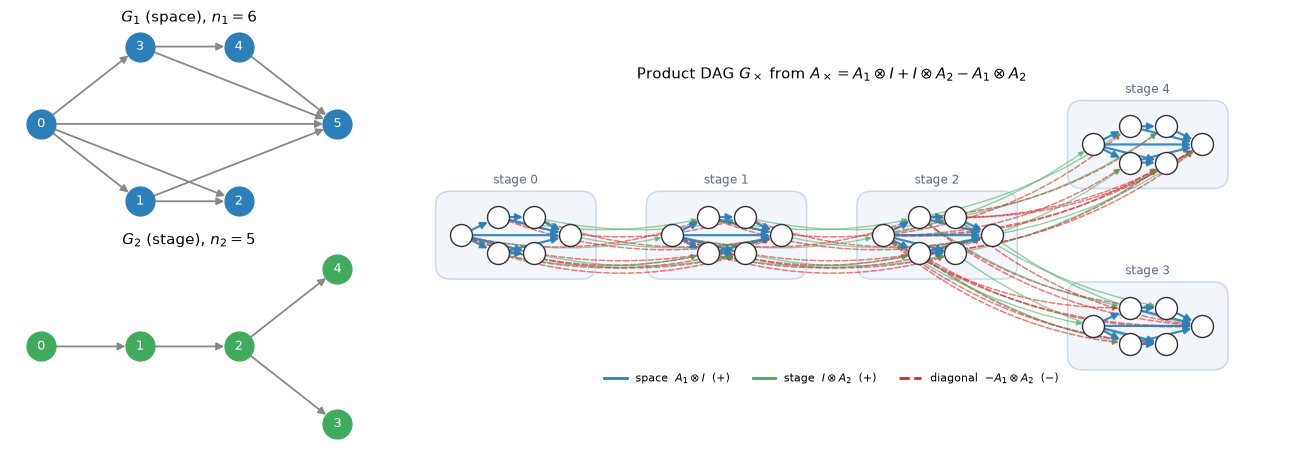

In [4]:
fig=plt.figure(figsize=(13,4.6)); gs=fig.add_gridspec(2,2,width_ratios=[1,2.5])
axa=fig.add_subplot(gs[0,0]); axb=fig.add_subplot(gs[1,0]); axc=fig.add_subplot(gs[:,1])
nx.draw_networkx(G1,pos1,ax=axa,node_color=C0,node_size=430,font_color='white',font_size=9,
                 edge_color='#888',arrows=True,arrowsize=11,width=1.3); axa.set_title(r'$G_1$ (space), $n_1=%d$'%n1); axa.axis('off')
nx.draw_networkx(G2,pos2,ax=axb,node_color=Cg,node_size=430,font_color='white',font_size=9,
                 edge_color='#888',arrows=True,arrowsize=11,width=1.3); axb.set_title(r'$G_2$ (stage), $n_2=%d$'%n2); axb.axis('off')
draw_boxes(axc)
# ===== Plot G_x from the operator adjacency A_x (run after the bundle cell) =====
F1,F2=np.eye(n1)-A1,np.eye(n2)-A2
A_x=np.eye(n1*n2)-np.kron(F1,F2)                 # A_x = A1⊗I + I⊗A2 - A1⊗A2
node=lambda k:(k//n2, k%n2)                      # flat index -> (i,j), matches np.kron(A1,I2)

e_space,e_stage,e_diag=[],[],[]
for c in range(n1*n2):
    for p in range(n1*n2):
        if abs(A_x[c,p])<1e-12: continue
        (ic,jc),(ip,jp)=node(c),node(p)
        if   jc==jp: e_space.append((node(p),node(c)))     # A1⊗I   (+)
        elif ic==ip: e_stage.append((node(p),node(c)))     # I⊗A2   (+)
        else:        e_diag.append((node(p),node(c)))       # -A1⊗A2 (−)

#fig,ax=plt.subplots(figsize=(9,6)); draw_boxes(ax)
nx.draw_networkx_edges(Gx,posx,edgelist=e_diag ,ax=axc,edge_color='#d62728',style='dashed',width=1.1,alpha=.6,arrows=True,arrowsize=8,connectionstyle='arc3,rad=0.16',node_size=250)
nx.draw_networkx_edges(Gx,posx,edgelist=e_stage,ax=axc,edge_color=Cg,width=1.0,alpha=.55,arrows=True,arrowsize=8,connectionstyle='arc3,rad=0.12',node_size=250)
nx.draw_networkx_edges(Gx,posx,edgelist=e_space,ax=axc,edge_color=C0,width=1.6,alpha=.9,arrows=True,arrowsize=10,node_size=250)
nx.draw_networkx_nodes(Gx,posx,ax=axc,node_color='#fff',edgecolors='#333',linewidths=1.0,node_size=250)
from matplotlib.lines import Line2D
axc.legend(handles=[Line2D([0],[0],color=C0,lw=2,label=r'space  $A_1\otimes I$  (+)'),
                   Line2D([0],[0],color=Cg,lw=2,label=r'stage  $I\otimes A_2$  (+)'),
                   Line2D([0],[0],color='#d62728',lw=2,ls='--',label=r'diagonal  $-A_1\otimes A_2$  ($-$)')],
          fontsize=8,loc='lower center',frameon=False,ncol=3,bbox_to_anchor=(.5,-.04))
axc.set_title(r'Product DAG $G_\times$ from $A_\times=A_1\otimes I+I\otimes A_2-A_1\otimes A_2$')
axc.axis('off'); axc.set_aspect('equal'); plt.tight_layout(); plt.show()

## 3. Low-pass signal, white noise
Clean signals have a **separable low-pass** power spectrum
$\mathbb E|\vecx C_{ij}|^2=\rho_1^{\mathrm{depth}_1(i)}\rho_2^{\mathrm{depth}_2(j)}$, so the field varies
smoothly over the DAG. Here the optimal filter is separable, and ALS should match or beat the
unconstrained fit.

white noise, 4 dB held-out NMSE:
  no filter          0.398
  separable (ALS)    0.250
  unconstrained      0.263
  sigma2/sigma1(unconstrained)=0.105   params: separable n1+n2=11 vs full n1*n2=30


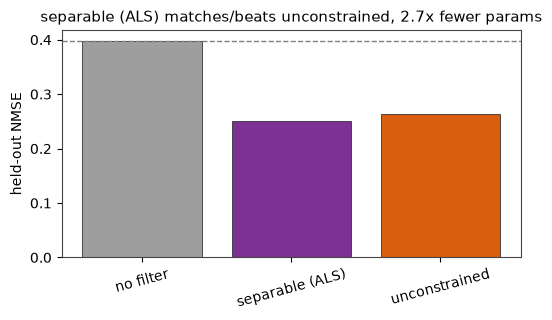

In [5]:
def gen(P,rng,r1=.30,r2=.34,floor=.015):
    Pw=(r1**d1)[:,None]*(r2**d2)[None,:]+floor
    return P.syn(np.sqrt(Pw)*rng.standard_normal((P.n1,P.n2)))
def add_white(S,snr,rng):
    e=rng.standard_normal(S.shape); c=S-S.mean(); e*=np.sqrt(np.sum(c**2)/np.sum(e**2)/10**(snr/10)); return S+e

def experiment(noise,snr,ntr=60,ntest=80,seed=7):
    r=np.random.default_rng(seed)
    Sc=[gen(P,r) for _ in range(ntr)]; Yn=[noise(s,snr,r) for s in Sc]
    Hf=fit_full(P,Yn,Sc); Htil,h1,h2,th1,th2=fit_als(P,Yn,Sc)
    St=[gen(P,r) for _ in range(ntest)]; Yt=[noise(s,snr,r) for s in St]
    f=lambda H:np.mean([nmse(s,P.apply(y,H)) for s,y in zip(St,Yt)])
    u,sv,vt=np.linalg.svd(Hf)
    res={'no filter':np.mean([nmse(s,y) for s,y in zip(St,Yt)]),
         'separable (ALS)':f(Htil),'unconstrained':f(Hf)}
    return res,Hf,Htil,sv[1]/sv[0]

resA,HfA,HtA,s21A=experiment(add_white,4)
print('white noise, 4 dB held-out NMSE:')
for k,v in resA.items(): print('  %-18s %.3f'%(k,v))
print('  sigma2/sigma1(unconstrained)=%.3f   params: separable n1+n2=%d vs full n1*n2=%d'%(s21A,n1+n2,n1*n2))
fig,ax=plt.subplots(figsize=(5.5,3.3))
ax.bar(list(resA),list(resA.values()),color=['#9e9e9e','#7b3294','#d95f0e'],edgecolor='#333',lw=.6)
ax.axhline(resA['no filter'],ls='--',c='gray',lw=1); ax.set_ylabel('held-out NMSE')
ax.set_title('separable (ALS) matches/beats unconstrained, %.1fx fewer params'%(n1*n2/(n1+n2)))
ax.tick_params(axis='x',rotation=15); plt.tight_layout(); plt.show()

## 4. Low-pass heat map: noisy vs. denoised signal on the DAG
One held-out field, using the *same* fitted filters (`HfA`, `HtA`) and reporting the *same*
held-out NMSE (`resA`) as the Sec. 3 bar chart — this illustrates that reported result rather than
showing a separate one-off example.

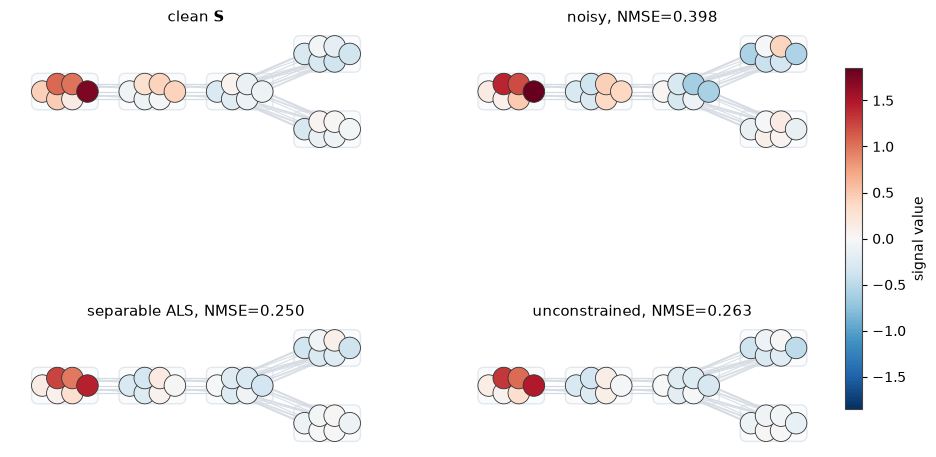

In [6]:
rv=np.random.default_rng(3000); Scl=gen(P,rv); Sno=add_white(Scl,4,rv)   # SNR must match Sec. 3
Sals,Sful=P.apply(Sno,HtA),P.apply(Sno,HfA)
panels=[(Scl,'clean $\\mathbf{S}$'),
        (Sno,'noisy, NMSE=%.3f'%resA['no filter']),
        (Sals,'separable ALS, NMSE=%.3f'%resA['separable (ALS)']),
        (Sful,'unconstrained, NMSE=%.3f'%resA['unconstrained'])]
vmax=np.abs(np.stack([Scl,Sno,Sals,Sful])).max()
fig,axes=plt.subplots(2,2,figsize=(11,7))
for a,(F,t) in zip(axes.ravel(),panels):
    draw_boxes(a,fc='#fafbfc',ec='#e3e8ef',lw=1.0,label=False)
    nx.draw_networkx_edges(Gx,posx,edgelist=e_diag+espace+estage,ax=a,edge_color='#d5dbe3',width=.8,arrows=False,alpha=.9)
    nd=nx.draw_networkx_nodes(Gx,posx,ax=a,node_color=[F[i,j] for (i,j) in Gx.nodes()],cmap='RdBu_r',
                              vmin=-vmax,vmax=vmax,node_size=240,edgecolors='#333',linewidths=.6)
    a.set_title(t); a.axis('off'); a.set_aspect('equal')
fig.colorbar(nd,ax=axes,fraction=0.02,pad=0.02,label='signal value')
plt.show()

## 6. Computational advantage

parameters:  separable n1+n2=11   |   full n1*n2=30   (2.7x fewer)


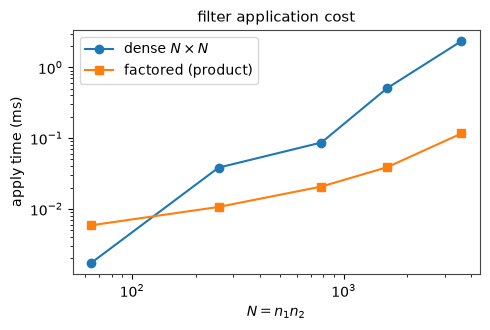

at N=3600: factored is 20x faster


In [11]:
print('parameters:  separable n1+n2=%d   |   full n1*n2=%d   (%.1fx fewer)'%(n1+n2,n1*n2,(n1*n2)/(n1+n2)))
sizes=[(8,8),(16,16),(28,28),(40,40),(60,60)]; Ns,tf,td=[],[],[]; rr=np.random.default_rng(0)
for (p,q) in sizes:
    Pp=Prod(rdag(p,.2,rr),rdag(q,.2,rr)); Hm=rr.standard_normal((p,q)); Y=rr.standard_normal((p,q)); reps=50
    t0=time.perf_counter()
    for _ in range(reps): _=Pp.apply(Y,Hm)
    tf.append((time.perf_counter()-t0)/reps*1e3)
    Op=np.kron(Pp.W1,Pp.W2)@np.diag(Hm.ravel())@np.kron(Pp.F1,Pp.F2); y=Y.ravel()
    t0=time.perf_counter()
    for _ in range(reps): _=Op@y
    td.append((time.perf_counter()-t0)/reps*1e3); Ns.append(p*q)
plt.figure(figsize=(5,3.4))
plt.loglog(Ns,td,'o-',label=r'dense $N\times N$'); plt.loglog(Ns,tf,'s-',label='factored (product)')
plt.xlabel(r'$N=n_1n_2$'); plt.ylabel('apply time (ms)'); plt.title('filter application cost'); plt.legend()
plt.tight_layout(); plt.show()
print('at N=%d: factored is %.0fx faster'%(Ns[-1],td[-1]/tf[-1]))

Plots for paper

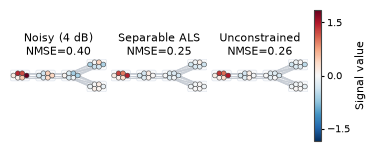

In [12]:
panels = [
        (Sno,'Noisy (4 dB)\nNMSE=%.2f'% resA['no filter']),
        (Sals,'Separable ALS\nNMSE=%.2f'% resA['separable (ALS)']),
        (Sful,'Unconstrained\nNMSE=%.2f'% resA['unconstrained'])
        ]

vmax = max(abs(Sno).max(), abs(Sals).max(), abs(Sful).max())

# Close to the final printed width.
fig, axes = plt.subplots(
    1, 3, figsize=(3.6, 1.35),
    layout='constrained'
)
fig.get_layout_engine().set(
    w_pad=0.02, h_pad=0.02, wspace=0.02
)

# Tight limits, including the rounded boxes drawn by draw_boxes().
xy = np.asarray(list(posx.values()))
pad = 0.48  # draw_boxes() uses approximately 0.42 padding

for a, (F, title) in zip(axes, panels):
    draw_boxes(
        a, fc='#fafbfc', ec='#e3e8ef',
        lw=0.6, label=False
    )

    nx.draw_networkx_edges(
        Gx, posx,
        edgelist=e_diag + espace + estage,
        ax=a, edge_color='#c5cbd3',
        width=0.5, arrows=False, alpha=0.9
    )

    nd = nx.draw_networkx_nodes(
        Gx, posx, ax=a,
        node_color=[F[i, j] for i, j in Gx.nodes()],
        cmap='RdBu_r', vmin=-vmax, vmax=vmax,
        node_size=12, edgecolors='#333', linewidths=0.35
    )

    a.set_title(title, fontsize=8, pad=3)
    a.set_xlim(xy[:, 0].min() - pad, xy[:, 0].max() + pad)
    a.set_ylim(xy[:, 1].min() - pad, xy[:, 1].max() + pad)
    a.set_aspect('equal')
    a.axis('off')

cbar = fig.colorbar(
    nd, ax=axes, fraction=0.025, pad=0.02, aspect=18
)
cbar.set_label('Signal value', fontsize=8, labelpad=3)
cbar.ax.tick_params(labelsize=7, length=2, pad=2)
cbar.locator = mpl.ticker.MaxNLocator(nbins=3)
cbar.update_ticks()

# PDF preserves sharp text and graph edges.
fig.savefig(
    'noisy_als_unconstrained.pdf',
    bbox_inches='tight', pad_inches=0.02
)
fig.savefig(
    'noisy_als_unconstrained.png',
    dpi=400, bbox_inches='tight', pad_inches=0.02
)

plt.show()

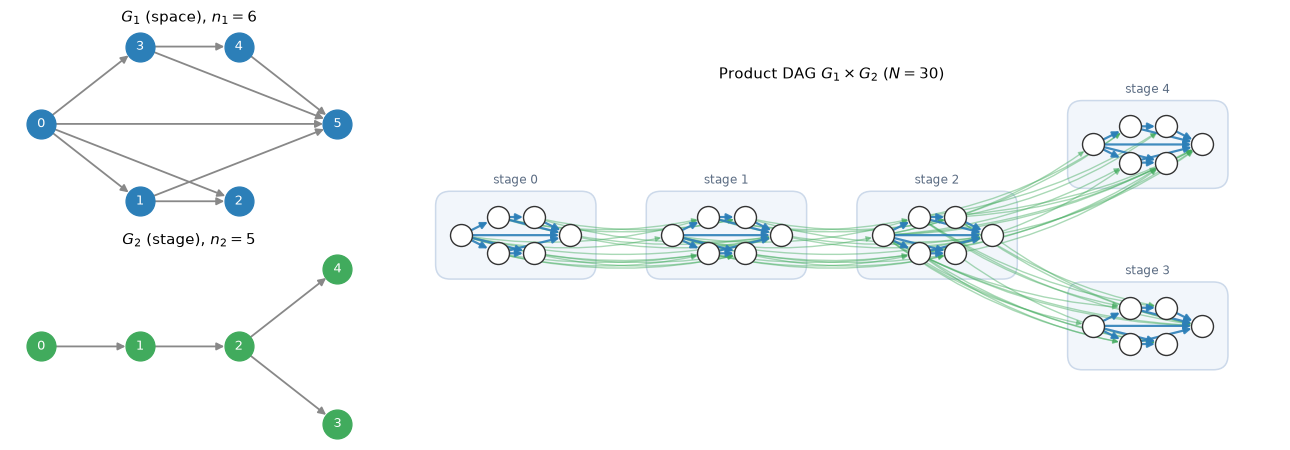

In [13]:
fig=plt.figure(figsize=(13,4.6)); gs=fig.add_gridspec(2,2,width_ratios=[1,2.5])
axa=fig.add_subplot(gs[0,0]); axb=fig.add_subplot(gs[1,0]); axc=fig.add_subplot(gs[:,1])
nx.draw_networkx(G1,pos1,ax=axa,node_color=C0,node_size=430,font_color='white',font_size=9,
                 edge_color='#888',arrows=True,arrowsize=11,width=1.3); axa.set_title(r'$G_1$ (space), $n_1=%d$'%n1); axa.axis('off')
nx.draw_networkx(G2,pos2,ax=axb,node_color=Cg,node_size=430,font_color='white',font_size=9,
                 edge_color='#888',arrows=True,arrowsize=11,width=1.3); axb.set_title(r'$G_2$ (stage), $n_2=%d$'%n2); axb.axis('off')
draw_boxes(axc)
nx.draw_networkx_edges(Gx,posx,edgelist=e_diag+estage,ax=axc,edge_color=Cg,width=1.0,alpha=.45,arrows=True,arrowsize=8,connectionstyle='arc3,rad=0.12',node_size=250)
nx.draw_networkx_edges(Gx,posx,edgelist=espace,ax=axc,edge_color=C0,width=1.6,alpha=.9,arrows=True,arrowsize=10,node_size=250)
nx.draw_networkx_nodes(Gx,posx,ax=axc,node_color='#fff',edgecolors='#333',linewidths=1.0,node_size=250)
axc.set_title(r'Product DAG $G_1\times G_2$ ($N=%d$)'%(n1*n2)); axc.axis('off'); axc.set_aspect('equal')
plt.tight_layout(); plt.savefig('factor_dag.png', dpi=200, bbox_inches='tight'); plt.show()


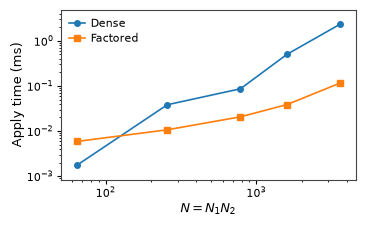

at N=3600: factored is 20x faster


In [14]:
# Match the intended width in the paper.
# Use about 3.5 inches for a full column.
fig, ax = plt.subplots(
    figsize=(3.5, 2.1),
    layout='constrained'
)
fig.get_layout_engine().set(w_pad=0.02, h_pad=0.02)

ax.loglog(
    Ns, td, 'o-', label='Dense',
    linewidth=1.2, markersize=4
)
ax.loglog(
    Ns, tf, 's-', label='Factored',
    linewidth=1.2, markersize=4
)

ax.set_xlabel(r'$N=N_1N_2$', fontsize=9, labelpad=2)
ax.set_ylabel('Apply time (ms)', fontsize=9, labelpad=2)

ax.tick_params(
    axis='both', which='major',
    labelsize=8, length=3, pad=2
)
ax.tick_params(axis='both', which='minor', length=1.5)

ax.legend(
    fontsize=8, loc='upper left',
    frameon=False,
    handlelength=1.5, handletextpad=0.5,
    borderaxespad=0.3, labelspacing=0.3
)

ax.margins(x=0.06, y=0.10)

fig.savefig(
    'computational_advantage.pdf',
    bbox_inches='tight', pad_inches=0.02
)
fig.savefig(
    'computational_advantage.png',
    dpi=400, bbox_inches='tight', pad_inches=0.02
)
plt.show()

print('at N=%d: factored is %.0fx faster'
      % (Ns[-1], td[-1] / tf[-1]))

## Takeaways
* The ALS-fitted separable response $\tilde{\bf H}=\bf h_1\bf h_2^\top$ is a **low-pass** filter
  that **matches or beats** the unconstrained fit when the optimal filter is separable (as in this
  white-noise setup) — at $n_1+n_2$ instead of $n_1n_2$ parameters.
* Applying the filter is factored, $\hat{\bf S}=\bf W_1(\tilde{\bf H}\odot\bf C)\bf W_2^\top$:
  no $N\times N$ operator, no eigendecomposition.